In [11]:
from pathlib import Path
import pandas as pd


# ============================================================
# 0. Settings
# ============================================================

BASE_DATE = "JUN11"

pred_dir = Path(f"_json/_run/{BASE_DATE}/_prediction_daily")
eplus_path = pred_dir / "prediction_daily_EPlus_4P_FEBMAR.csv"

rc_run_ids = [
    "ETHlib_default_occ",
    "ETHlib_ONSITE_occ",
    "ETHlib_bldg_LoD_Y",
    "ETHlib_3R2C_default_occ",
    "ETHlib_3R2C_ONSITE_occ",
    "ETHlib_3R2C_bldg_LoD_Y",
]


# ============================================================
# 1. Group / label helpers
# ============================================================

label_map = {
    "_beta": r"LoD-1: $ihg^{1}_{1}$",
    "_gamma": r"LoD-2: $ihg^{2}_{1}$",
    "bY": r"LoD-3: $ihg^{3}_{1}$",
    "default_occ": "LoD-1: default occupancy",
    "ONSITE_occ": "LoD-2: on-site occupancy",
    "bldg_LoD_Y": "LoD-3: building LoD-Y occupancy",
}


def infer_eplus_group_from_text(text):
    text = str(text)

    if "4P__beta" in text or "_beta" in text:
        return "_beta"
    if "4P__gamma" in text or "_gamma" in text:
        return "_gamma"
    if "4P_bY" in text or "bY" in text:
        return "bY"

    return "unknown"


def infer_rc_model_name(run_label):
    if "ETHlib_3R2C" in run_label:
        return "3R2C"
    if "ETHlib" in run_label:
        return "5R1C"

    return "RC"


def infer_rc_group(run_label):
    if "default_occ" in run_label:
        return "default_occ"
    if "ONSITE_occ" in run_label:
        return "ONSITE_occ"
    if "bldg_LoD_Y" in run_label:
        return "bldg_LoD_Y"

    return "unknown"


# ============================================================
# 2. Load original E+ prediction_daily
# ============================================================

def load_original_eplus_prediction_daily(path):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Missing E+ file: {path}")

    df = pd.read_csv(path)
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    if "heating_energy" in df.columns and "sim_heating" not in df.columns:
        df = df.rename(columns={"heating_energy": "sim_heating"})

    if "Metering" in df.columns and "metered_heating" not in df.columns:
        df = df.rename(columns={"Metering": "metered_heating"})

    df["source"] = "EPlus"
    df["experiment_id"] = df.get("experiment_id", "EPlus_4P_FEBMAR")
    df["model_name"] = "EnergyPlus"

    df["scenario_group"] = df.apply(
        lambda row: infer_eplus_group_from_text(
            " ".join([
                str(row.get("scenario_group", "")),
                str(row.get("scenario_label", "")),
                str(row.get("sample_id", "")),
                str(row.get("experiment_id", "")),
            ])
        ),
        axis=1,
    )

    df["scenario_label"] = df["scenario_group"].map(label_map)

    keep_cols = [
        "source",
        "experiment_id",
        "model_name",
        "scenario_group",
        "scenario_label",
        "sample_id",
        "timestamp",
        "sim_heating",
        "metered_heating",
    ]

    missing = [c for c in keep_cols if c not in df.columns]
    if missing:
        raise ValueError(f"E+ file is missing columns: {missing}")

    return df[keep_cols].copy()


# ============================================================
# 3. Load original six RC prediction_daily files
# ============================================================

def load_original_rc_prediction_daily(base_date, rc_run_ids, metered_by_date=None):
    dfs = []
    missing_files = []

    for run_id in rc_run_ids:
        run_label = f"{base_date}__{run_id}"

        path = (
            Path(f"_json/_run/{run_label}")
            / "_outcome"
            / run_label
            / "baseline_prediction_daily.csv"
        )

        if not path.exists():
            missing_files.append(path)
            continue

        df = pd.read_csv(path)
        df["timestamp"] = pd.to_datetime(df["timestamp"])

        if "heating_energy" in df.columns and "sim_heating" not in df.columns:
            df = df.rename(columns={"heating_energy": "sim_heating"})

        if "sim_heating" not in df.columns:
            raise ValueError(
                f"{path} has no 'heating_energy' or 'sim_heating' column."
            )

        scenario_group = infer_rc_group(run_label)

        df["source"] = "RC"
        df["experiment_id"] = run_label
        df["model_name"] = infer_rc_model_name(run_label)
        df["scenario_group"] = scenario_group
        df["scenario_label"] = label_map.get(scenario_group, scenario_group)

        if "metered_heating" not in df.columns:
            if metered_by_date is not None:
                df = df.merge(
                    metered_by_date,
                    on="timestamp",
                    how="left",
                )
            else:
                df["metered_heating"] = pd.NA

        keep_cols = [
            "source",
            "experiment_id",
            "model_name",
            "scenario_group",
            "scenario_label",
            "sample_id",
            "timestamp",
            "sim_heating",
            "metered_heating",
        ]

        dfs.append(df[keep_cols].copy())

    if missing_files:
        print("[WARN] Missing RC files:")
        for path in missing_files:
            print("   ", path)

    if not dfs:
        raise ValueError("No RC prediction files were loaded.")

    return pd.concat(dfs, ignore_index=True)


# ============================================================
# 4. Build prediction_daily from originals only
# ============================================================

prediction_daily_eplus = load_original_eplus_prediction_daily(eplus_path)

metered_by_date = (
    prediction_daily_eplus[["timestamp", "metered_heating"]]
    .dropna()
    .drop_duplicates(subset=["timestamp"])
    .copy()
)

prediction_daily_rc = load_original_rc_prediction_daily(
    base_date=BASE_DATE,
    rc_run_ids=rc_run_ids,
    metered_by_date=metered_by_date,
)

prediction_daily = pd.concat(
    [
        prediction_daily_eplus,
        prediction_daily_rc,
    ],
    ignore_index=True,
)

prediction_daily = prediction_daily.sort_values(
    [
        "source",
        "model_name",
        "scenario_group",
        "sample_id",
        "timestamp",
    ]
).reset_index(drop=True)


# ============================================================
# 5. Check
# ============================================================

display(
    prediction_daily.groupby(
        ["source", "model_name", "scenario_group"]
    )["sample_id"].nunique()
)

source  model_name  scenario_group
EPlus   EnergyPlus  _beta             10
                    _gamma            10
                    bY                10
                    unknown           20
RC      3R2C        ONSITE_occ        10
                    bldg_LoD_Y        10
                    default_occ       10
        5R1C        ONSITE_occ        10
                    bldg_LoD_Y        10
                    default_occ       10
Name: sample_id, dtype: int64

In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

def add_engine_quality_keys(prediction_daily):
    df = prediction_daily.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    def engine_key(row):
        model = str(row.get("model_name", ""))
        source = str(row.get("source", ""))

        if source == "EPlus" or model == "EnergyPlus":
            return "EnergyPlus"
        if model == "5R1C":
            return "5R1C"
        if model == "3R2C":
            return "3R2C"

        return model

    df["engine_key"] = df.apply(engine_key, axis=1)

    quality_map = {
        "_beta": "LoD-1",
        "_gamma": "LoD-2",
        "bY": "LoD-3",
        "default_occ": "LoD-1",
        "ONSITE_occ": "LoD-2",
        "bldg_LoD_Y": "LoD-3",
    }

    df["data_quality"] = df["scenario_group"].map(quality_map)

    # Keep only LoD-1 to LoD-3
    df = df[df["data_quality"].notna()].copy()

    return df

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway



# ============================================================
# 1. Compute CVRMSE / NMBE per sample
# ============================================================

def calc_cvrmse_nmbe_daily(sim, obs):
    df = pd.concat(
        [
            sim.rename("sim"),
            obs.rename("obs"),
        ],
        axis=1,
    ).dropna()

    if len(df) < 2:
        return np.nan, np.nan

    error = df["obs"] - df["sim"]
    obs_mean = df["obs"].mean()

    if obs_mean == 0:
        return np.nan, np.nan

    rmse = np.sqrt(np.mean(error ** 2))

    cvrmse = rmse / obs_mean * 100.0
    nmbe = error.sum() / (len(df) * obs_mean) * 100.0

    return cvrmse, nmbe


def make_prediction_metric_df(
    prediction_daily,
    periods=None,
):
    df = add_engine_quality_keys(prediction_daily)

    df["timestamp"] = pd.to_datetime(df["timestamp"])

    # Keep only comparable 3 x 3 matrix
    df = df[
        df["engine_key"].isin(["5R1C", "3R2C", "EnergyPlus"])
        & df["data_quality"].isin(["LoD-1", "LoD-2", "LoD-3"])
    ].copy()

    if periods is None:
        periods = {
            "Full period": (
                df["timestamp"].min(),
                df["timestamp"].max(),
            )
        }

    rows = []

    for period_name, (start, end) in periods.items():
        d_period = df[
            (df["timestamp"] >= pd.to_datetime(start))
            & (df["timestamp"] <= pd.to_datetime(end))
        ].copy()

        for keys, d in d_period.groupby(
            [
                "source",
                "model_name",
                "engine_key",
                "data_quality",
                "scenario_group",
                "sample_id",
            ],
            observed=True,
        ):
            source, model_name, engine, data_quality, scenario_group, sample_id = keys

            d = d.sort_values("timestamp")

            sim = d.set_index("timestamp")["sim_heating"]
            obs = d.set_index("timestamp")["metered_heating"]

            cvrmse, nmbe = calc_cvrmse_nmbe_daily(sim, obs)

            rows.append(
                {
                    "Period": period_name,
                    "source": source,
                    "model_name": model_name,
                    "engine": engine,
                    "data_quality": data_quality,
                    "scenario_group": scenario_group,
                    "sample_id": sample_id,
                    "n_days": len(d),
                    "CVRMSE": cvrmse,
                    "NMBE": nmbe,
                    "absNMBE": abs(nmbe),
                    "GOF": np.sqrt(cvrmse ** 2 + nmbe ** 2) / np.sqrt(2),
                }
            )

    metric_df = pd.DataFrame(rows)

    metric_df["engine"] = pd.Categorical(
        metric_df["engine"],
        categories=["5R1C", "3R2C", "EnergyPlus"],
        ordered=True,
    )

    metric_df["data_quality"] = pd.Categorical(
        metric_df["data_quality"],
        categories=["LoD-1", "LoD-2", "LoD-3"],
        ordered=True,
    )

    return metric_df
import numpy as np
import pandas as pd
from pathlib import Path


# ============================================================
# 1. Aggregated energy-use table per posterior sample
# ============================================================

def make_aggregated_energy_df(
    prediction_daily,
    periods=None,
    value_col="sim_heating",
):
    df = add_engine_quality_keys(prediction_daily)

    df["timestamp"] = pd.to_datetime(df["timestamp"])

    df = df[
        df["engine_key"].isin(["5R1C", "3R2C", "EnergyPlus"])
        & df["data_quality"].isin(["LoD-1", "LoD-2", "LoD-3"])
    ].copy()

    if periods is None:
        periods = {
            "Full period": (
                df["timestamp"].min(),
                df["timestamp"].max(),
            )
        }

    rows = []

    for period_name, (start, end) in periods.items():
        d_period = df[
            (df["timestamp"] >= pd.to_datetime(start))
            & (df["timestamp"] <= pd.to_datetime(end))
        ].copy()

        for keys, d in d_period.groupby(
            [
                "source",
                "model_name",
                "engine_key",
                "data_quality",
                "scenario_group",
                "sample_id",
            ],
            observed=True,
        ):
            source, model_name, engine, data_quality, scenario_group, sample_id = keys

            rows.append(
                {
                    "Period": period_name,
                    "source": source,
                    "model_name": model_name,
                    "engine": engine,
                    "data_quality": data_quality,
                    "scenario_group": scenario_group,
                    "sample_id": sample_id,
                    "n_days": d["timestamp"].nunique(),
                    "Energy_use": d[value_col].sum(),
                    "Metered_energy_use": d["metered_heating"].dropna().sum(),
                }
            )

    energy_df = pd.DataFrame(rows)

    energy_df["engine"] = pd.Categorical(
        energy_df["engine"],
        categories=["5R1C", "3R2C", "EnergyPlus"],
        ordered=True,
    )

    energy_df["data_quality"] = pd.Categorical(
        energy_df["data_quality"],
        categories=["LoD-1", "LoD-2", "LoD-3"],
        ordered=True,
    )

    return energy_df
import numpy as np
import pandas as pd
from scipy.stats import f


# ============================================================
# Two-way ANOVA without statsmodels
# Factors:
#   1. engine: 5R1C, 3R2C, EnergyPlus
#   2. data_quality: LoD-1, LoD-2, LoD-3
# ============================================================

def _make_design_matrix(df, include_engine=True, include_quality=True, include_interaction=False):
    X_parts = [
        pd.Series(1.0, index=df.index, name="Intercept")
    ]

    engine_dummies = None
    quality_dummies = None

    if include_engine:
        engine_dummies = pd.get_dummies(
            df["engine"].astype(str),
            prefix="engine",
            drop_first=True,
            dtype=float,
        )
        X_parts.append(engine_dummies)

    if include_quality:
        quality_dummies = pd.get_dummies(
            df["data_quality"].astype(str),
            prefix="quality",
            drop_first=True,
            dtype=float,
        )
        X_parts.append(quality_dummies)

    if include_interaction:
        if engine_dummies is None:
            engine_dummies = pd.get_dummies(
                df["engine"].astype(str),
                prefix="engine",
                drop_first=True,
                dtype=float,
            )

        if quality_dummies is None:
            quality_dummies = pd.get_dummies(
                df["data_quality"].astype(str),
                prefix="quality",
                drop_first=True,
                dtype=float,
            )

        interaction_terms = {}

        for e_col in engine_dummies.columns:
            for q_col in quality_dummies.columns:
                interaction_terms[f"{e_col}:{q_col}"] = (
                    engine_dummies[e_col] * quality_dummies[q_col]
                )

        if interaction_terms:
            X_parts.append(pd.DataFrame(interaction_terms, index=df.index))

    X = pd.concat(X_parts, axis=1)
    return X.astype(float)


def _fit_ols_sse(y, X):
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)

    valid = np.isfinite(y) & np.all(np.isfinite(X), axis=1)

    y = y[valid]
    X = X[valid]

    beta, _, rank, _ = np.linalg.lstsq(X, y, rcond=None)

    residual = y - X @ beta
    sse = np.sum(residual ** 2)

    n = len(y)
    df_resid = n - rank

    return {
        "sse": sse,
        "rank": rank,
        "n": n,
        "df_resid": df_resid,
    }


def _nested_f_test(reduced, full):
    ss_effect = reduced["sse"] - full["sse"]
    df_effect = reduced["df_resid"] - full["df_resid"]

    ms_effect = ss_effect / df_effect
    ms_error = full["sse"] / full["df_resid"]

    F_value = ms_effect / ms_error
    p_value = f.sf(F_value, df_effect, full["df_resid"])

    return ss_effect, df_effect, F_value, p_value


def run_two_way_anova_no_statsmodels(
    metric_df,
    response="CVRMSE",
    period="Full period",
):
    d = metric_df[metric_df["Period"] == period].copy()

    d = d.dropna(
        subset=[
            response,
            "engine",
            "data_quality",
        ]
    )

    d = d[
        d["engine"].isin(["5R1C", "3R2C", "EnergyPlus"])
        & d["data_quality"].isin(["LoD-1", "LoD-2", "LoD-3"])
    ].copy()

    y = d[response].astype(float)

    # Reduced and full models
    X_intercept = _make_design_matrix(
        d,
        include_engine=False,
        include_quality=False,
        include_interaction=False,
    )

    X_engine = _make_design_matrix(
        d,
        include_engine=True,
        include_quality=False,
        include_interaction=False,
    )

    X_quality = _make_design_matrix(
        d,
        include_engine=False,
        include_quality=True,
        include_interaction=False,
    )

    X_additive = _make_design_matrix(
        d,
        include_engine=True,
        include_quality=True,
        include_interaction=False,
    )

    X_full = _make_design_matrix(
        d,
        include_engine=True,
        include_quality=True,
        include_interaction=True,
    )

    fit_intercept = _fit_ols_sse(y, X_intercept)
    fit_engine = _fit_ols_sse(y, X_engine)
    fit_quality = _fit_ols_sse(y, X_quality)
    fit_additive = _fit_ols_sse(y, X_additive)
    fit_full = _fit_ols_sse(y, X_full)

    rows = []

    # Engine effect, controlling for data quality
    ss, df_effect, F_value, p_value = _nested_f_test(
        reduced=fit_quality,
        full=fit_additive,
    )

    rows.append({
        "Period": period,
        "Response": response,
        "Effect": "Model complexity",
        "SS": ss,
        "df": df_effect,
        "F": F_value,
        "p_value": p_value,
        "Significant": p_value < 0.05,
    })

    # Data-quality effect, controlling for engine
    ss, df_effect, F_value, p_value = _nested_f_test(
        reduced=fit_engine,
        full=fit_additive,
    )

    rows.append({
        "Period": period,
        "Response": response,
        "Effect": "Data quality",
        "SS": ss,
        "df": df_effect,
        "F": F_value,
        "p_value": p_value,
        "Significant": p_value < 0.05,
    })

    # Interaction effect
    ss, df_effect, F_value, p_value = _nested_f_test(
        reduced=fit_additive,
        full=fit_full,
    )

    rows.append({
        "Period": period,
        "Response": response,
        "Effect": "Model complexity × Data quality",
        "SS": ss,
        "df": df_effect,
        "F": F_value,
        "p_value": p_value,
        "Significant": p_value < 0.05,
    })

    return pd.DataFrame(rows)


In [14]:
energy_df = make_aggregated_energy_df(
    prediction_daily,
    periods={
        "Full period": ("2023-01-20", "2023-03-17"),
    },
)

display(
    energy_df.groupby(
        ["Period", "engine", "data_quality"],
        observed=True,
    )["sample_id"].nunique()
)

anova_energy_use = run_two_way_anova_no_statsmodels(
    energy_df,
    response="Energy_use",
    period="Full period",
)

anova_export = anova_energy_use.copy()

# Format p-values
anova_export["p_value"] = anova_export["p_value"].apply(
    lambda p: "< 0.001" if p < 0.001 else f"{p:.3f}"
)

# Round other numeric columns to 3 decimals
cols_to_round = ["SS", "F"]

for col in cols_to_round:
    if col in anova_export.columns:
        anova_export[col] = anova_export[col].round(3)

anova_export.to_csv("1.csv", index=False)

display(anova_export)

Period       engine      data_quality
Full period  5R1C        LoD-1           10
                         LoD-2           10
                         LoD-3           10
             3R2C        LoD-1           10
                         LoD-2           10
                         LoD-3           10
             EnergyPlus  LoD-1           10
                         LoD-2           10
                         LoD-3           10
Name: sample_id, dtype: int64

,Period,Response,Effect,SS,df,F,p_value,Significant
0,Full period,Energy_use,Model complexity,73.758,2,19.843,< 0.001,True
1,Full period,Energy_use,Data quality,30.046,2,8.083,< 0.001,True
2,Full period,Energy_use,Model complexity × Data quality,26.646,4,4.109,0.004,True


In [15]:
metric_df = make_prediction_metric_df(
    prediction_daily,
    periods={
        "Full period": ("2023-01-20", "2023-03-17"),
    },
)

display(
    metric_df.groupby(
        ["Period", "engine", "data_quality"],
        observed=True,
    )["sample_id"].nunique()
)

Period       engine      data_quality
Full period  5R1C        LoD-1           10
                         LoD-2           10
                         LoD-3           10
             3R2C        LoD-1           10
                         LoD-2           10
                         LoD-3           10
             EnergyPlus  LoD-1           10
                         LoD-2           10
                         LoD-3           10
Name: sample_id, dtype: int64

In [16]:
anova_prediction_metrics = pd.concat(
    [
        run_two_way_anova_no_statsmodels(metric_df, "CVRMSE", "Full period"),
        run_two_way_anova_no_statsmodels(metric_df, "NMBE", "Full period"),
        run_two_way_anova_no_statsmodels(metric_df, "absNMBE", "Full period"),
    ],
    ignore_index=True,
)

display(anova_prediction_metrics)

,Period,Response,Effect,SS,df,F,p_value,Significant
0,Full period,CVRMSE,Model complexity,2235.349275,2,62.526669,2.001229e-17,True
1,Full period,CVRMSE,Data quality,2019.542873,2,56.490183,2.476647e-16,True
2,Full period,CVRMSE,Model complexity × Data quality,541.322132,4,11.207589,2.758523e-07,True
3,Full period,NMBE,Model complexity,2765.464502,2,19.842718,8.474923e-08,True
4,Full period,NMBE,Data quality,1126.547675,2,8.083188,6.113168e-04,True
5,Full period,NMBE,Model complexity × Data quality,999.060407,4,4.108536,4.412288e-03,True
6,Full period,absNMBE,Model complexity,1815.340679,2,17.956083,3.128451e-07,True
7,Full period,absNMBE,Data quality,614.496810,2,6.078174,3.410196e-03,True
8,Full period,absNMBE,Model complexity × Data quality,675.410992,4,3.776848,7.231751e-03,True


In [17]:
from pathlib import Path
import numpy as np
import pandas as pd


def make_elbow_table(
    metric_df,
    period="Full period",
    elbow_threshold=0.25,
    engine_order=("5R1C", "3R2C", "EnergyPlus"),
    quality_order=("LoD-1", "LoD-2", "LoD-3"),
):
    df = metric_df[metric_df["Period"] == period].copy()

    if "absNMBE" not in df.columns:
        df["absNMBE"] = df["NMBE"].abs()

    metrics = {
        "CVRMSE": "CVRMSE",
        "|NMBE|": "absNMBE",
    }

    rows = []

    for metric_label, metric_col in metrics.items():
        matrix = (
            df.pivot_table(
                index="engine",
                columns="data_quality",
                values=metric_col,
                aggfunc="median",
                observed=True,
            )
            .reindex(index=engine_order, columns=quality_order)
        )

        for engine in engine_order:
            lod1 = matrix.loc[engine, "LoD-1"]
            lod2 = matrix.loc[engine, "LoD-2"]
            lod3 = matrix.loc[engine, "LoD-3"]

            gain_12 = lod1 - lod2
            gain_23 = lod2 - lod3

            if pd.notna(gain_12) and gain_12 > 0:
                elbow_ratio = gain_23 / gain_12
            else:
                elbow_ratio = np.nan

            values = {
                "LoD-1": lod1,
                "LoD-2": lod2,
                "LoD-3": lod3,
            }

            best_lod = min(values, key=values.get)

            if (
                pd.notna(elbow_ratio)
                and gain_12 > 0
                and gain_23 >= 0
                and elbow_ratio < elbow_threshold
            ):
                suggested_lod = "LoD-2"
                interpretation = "Elbow at LoD-2"
            elif best_lod == "LoD-3":
                suggested_lod = "LoD-3"
                interpretation = "Further improvement at LoD-3"
            else:
                suggested_lod = best_lod
                interpretation = "No clear elbow"

            rows.append(
                {
                    "Period": period,
                    "Model form": engine,
                    "Metric": metric_label,
                    "LoD-1": lod1,
                    "LoD-2": lod2,
                    "LoD-3": lod3,
                    "Gain LoD-1 to LoD-2": gain_12,
                    "Gain LoD-2 to LoD-3": gain_23,
                    "Elbow ratio": elbow_ratio,
                    "Suggested LoD": suggested_lod,
                    "Interpretation": interpretation,
                }
            )

    out = pd.DataFrame(rows)

    return out


elbow_table = make_elbow_table(
    metric_df=metric_df,
    period="Full period",
    elbow_threshold=0.25,
)

display(elbow_table.round(3))

,Period,Model form,Metric,LoD-1,LoD-2,LoD-3,Gain LoD-1 to LoD-2,Gain LoD-2 to LoD-3,Elbow ratio,Suggested LoD,Interpretation
0,Full period,5R1C,CVRMSE,45.132,43.332,29.962,1.800,13.371,7.428,LoD-3,Further improvement at LoD-3
1,Full period,3R2C,CVRMSE,44.650,42.986,32.040,1.665,10.946,6.575,LoD-3,Further improvement at LoD-3
2,Full period,EnergyPlus,CVRMSE,29.917,29.482,24.179,0.435,5.302,12.181,LoD-3,Further improvement at LoD-3
3,Full period,5R1C,|NMBE|,6.091,13.293,10.046,-7.202,3.247,NaN,LoD-1,No clear elbow
4,Full period,3R2C,|NMBE|,4.651,15.325,11.658,-10.674,3.667,NaN,LoD-1,No clear elbow
5,Full period,EnergyPlus,|NMBE|,21.530,20.786,11.464,0.744,9.322,12.533,LoD-3,Further improvement at LoD-3


In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def plot_prediction_metric_boxplots_by_engine(
    metric_df,
    period="Hold-out period",
):
    engine_order = ["EnergyPlus", "5R1C", "3R2C"]
    quality_order = ["LoD-1", "LoD-2", "LoD-3"]
    metric_order = ["CVRMSE", "NMBE", "GOF"]

    quality_display_map = {
        "LoD-1": "$LoD_d$=1",
        "LoD-2": "$LoD_d$=2",
        "LoD-3": "$LoD_d$=3",
    }

    metric_display_map = {
        "CVRMSE": "CVRMSE",
        "NMBE": "NMBE",
        "GOF": "GOF",
    }

    # Same family as earlier plots
    metric_palette = {
        "CVRMSE": "red",
        "NMBE": "blue",
        "GOF": "green",
    }

    df = metric_df.copy()

    if "engine_key" in df.columns and "engine" not in df.columns:
        df = df.rename(columns={"engine_key": "engine"})

    df = df[
        (df["Period"] == period)
        & (df["engine"].isin(engine_order))
        & (df["data_quality"].isin(quality_order))
    ].copy()

    plot_df = df.melt(
        id_vars=["Period", "engine", "data_quality", "sample_id"],
        value_vars=metric_order,
        var_name="Metric",
        value_name="Value",
    ).dropna(subset=["Value"])

    plot_df["engine"] = pd.Categorical(
        plot_df["engine"],
        categories=engine_order,
        ordered=True,
    )

    plot_df["data_quality"] = pd.Categorical(
        plot_df["data_quality"],
        categories=quality_order,
        ordered=True,
    )

    plot_df["Metric"] = pd.Categorical(
        plot_df["Metric"],
        categories=metric_order,
        ordered=True,
    )

    sns.set_theme(style="whitegrid")
    plt.rcParams["text.usetex"] = False

    fig, axes = plt.subplots(
        1,
        len(engine_order),
        figsize=(14, 4.8),
        sharey=True,
    )

    if len(engine_order) == 1:
        axes = [axes]

    for ax, engine in zip(axes, engine_order):
        d = plot_df[plot_df["engine"] == engine].copy()

        sns.boxplot(
            data=d,
            x="data_quality",
            y="Value",
            hue="Metric",
            order=quality_order,
            hue_order=metric_order,
            palette=metric_palette,
            showfliers=False,
            linewidth=1,
            width=0.72,
            saturation=0.45,
            ax=ax,
        )

        ax.set_title(engine)
        ax.set_xlabel("Data quality")
        ax.set_xticklabels([quality_display_map[q] for q in quality_order])
        ax.grid(True, axis="y", alpha=0.3)

        if ax is axes[0]:
            ax.set_ylabel("Metric value (%)")
        else:
            ax.set_ylabel("")

        # Grey borders like before
        for patch in ax.patches:
            patch.set_edgecolor("grey")
            patch.set_linewidth(1.0)

        for line in ax.lines:
            line.set_color("grey")
            line.set_linewidth(1.0)

    handles, labels = axes[-1].get_legend_handles_labels()
    axes[-1].legend(
        handles,
        [metric_display_map.get(x, x) for x in labels],
        title="Metric",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=True,
    )

    fig.suptitle(f"Prediction metrics across model form and data quality: {period}", y=1.03)

    plt.tight_layout()
    plt.show()

    return fig, axes, plot_df


In [22]:
metric_df = make_prediction_metric_df(
    prediction_daily,
    periods={
        "Full period": ("2023-01-20", "2023-03-17"),
    },
)

C:\Users\s2589602\AppData\Local\Temp\ipykernel_11628\3894096504.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([quality_display_map[q] for q in quality_order])
C:\Users\s2589602\AppData\Local\Temp\ipykernel_11628\3894096504.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([quality_display_map[q] for q in quality_order])
C:\Users\s2589602\AppData\Local\Temp\ipykernel_11628\3894096504.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([quality_display_map[q] for q in quality_order])


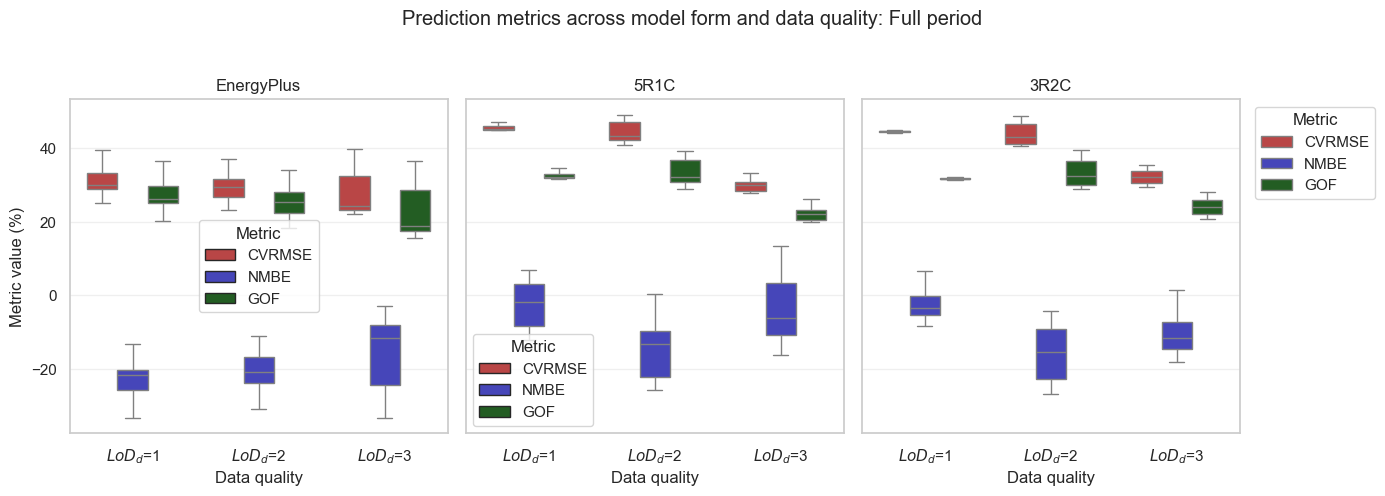

In [23]:
fig_metrics, axes_metrics, metric_plot_df = plot_prediction_metric_boxplots_by_engine(
    metric_df,
    period="Full period",
)